# K-Nearest Neighbours

## Importación de librerías, paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
# To save models
import json
import pickle
# Modelado
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
# Métricas
from sklearn.metrics import confusion_matrix, recall_score
from utils import get_classifier_metrics
from sklearn.model_selection import GridSearchCV, cross_val_score
# Warnings
import warnings

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Vamos a probar tres enfoques diferentes para la generación de este modelo:

1. Dataset truncado
2. Dataset con valores nulos remplazados por la moda
3. Dataset con valores nulos remplazados por los k-nearest neighbors


## 1. Dataset truncado:

### Cargamos el dataset procedente del eda previo

In [3]:
df_train_filtrado = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-filtrado.csv")
df_test_filtrado = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-filtrado.csv")

### Generamos los conjuntos de train y test

In [4]:
X_train_filtrado = df_train_filtrado.drop(["Outcome"], axis = 1)
y_train_filtrado = df_train_filtrado["Outcome"]
X_test_filtrado = df_test_filtrado.drop(["Outcome"], axis = 1)
y_test_filtrado = df_test_filtrado["Outcome"]
y_train_filtrado

0      1
1      0
2      0
3      1
4      1
      ..
309    1
310    1
311    0
312    0
313    1
Name: Outcome, Length: 314, dtype: int64

### Modelado y Ajuste

In [5]:
dt_classifier_model_filtrado = DecisionTreeClassifier(max_depth=5, random_state=24)
dt_classifier_model_filtrado.fit(X_train_filtrado, y_train_filtrado)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

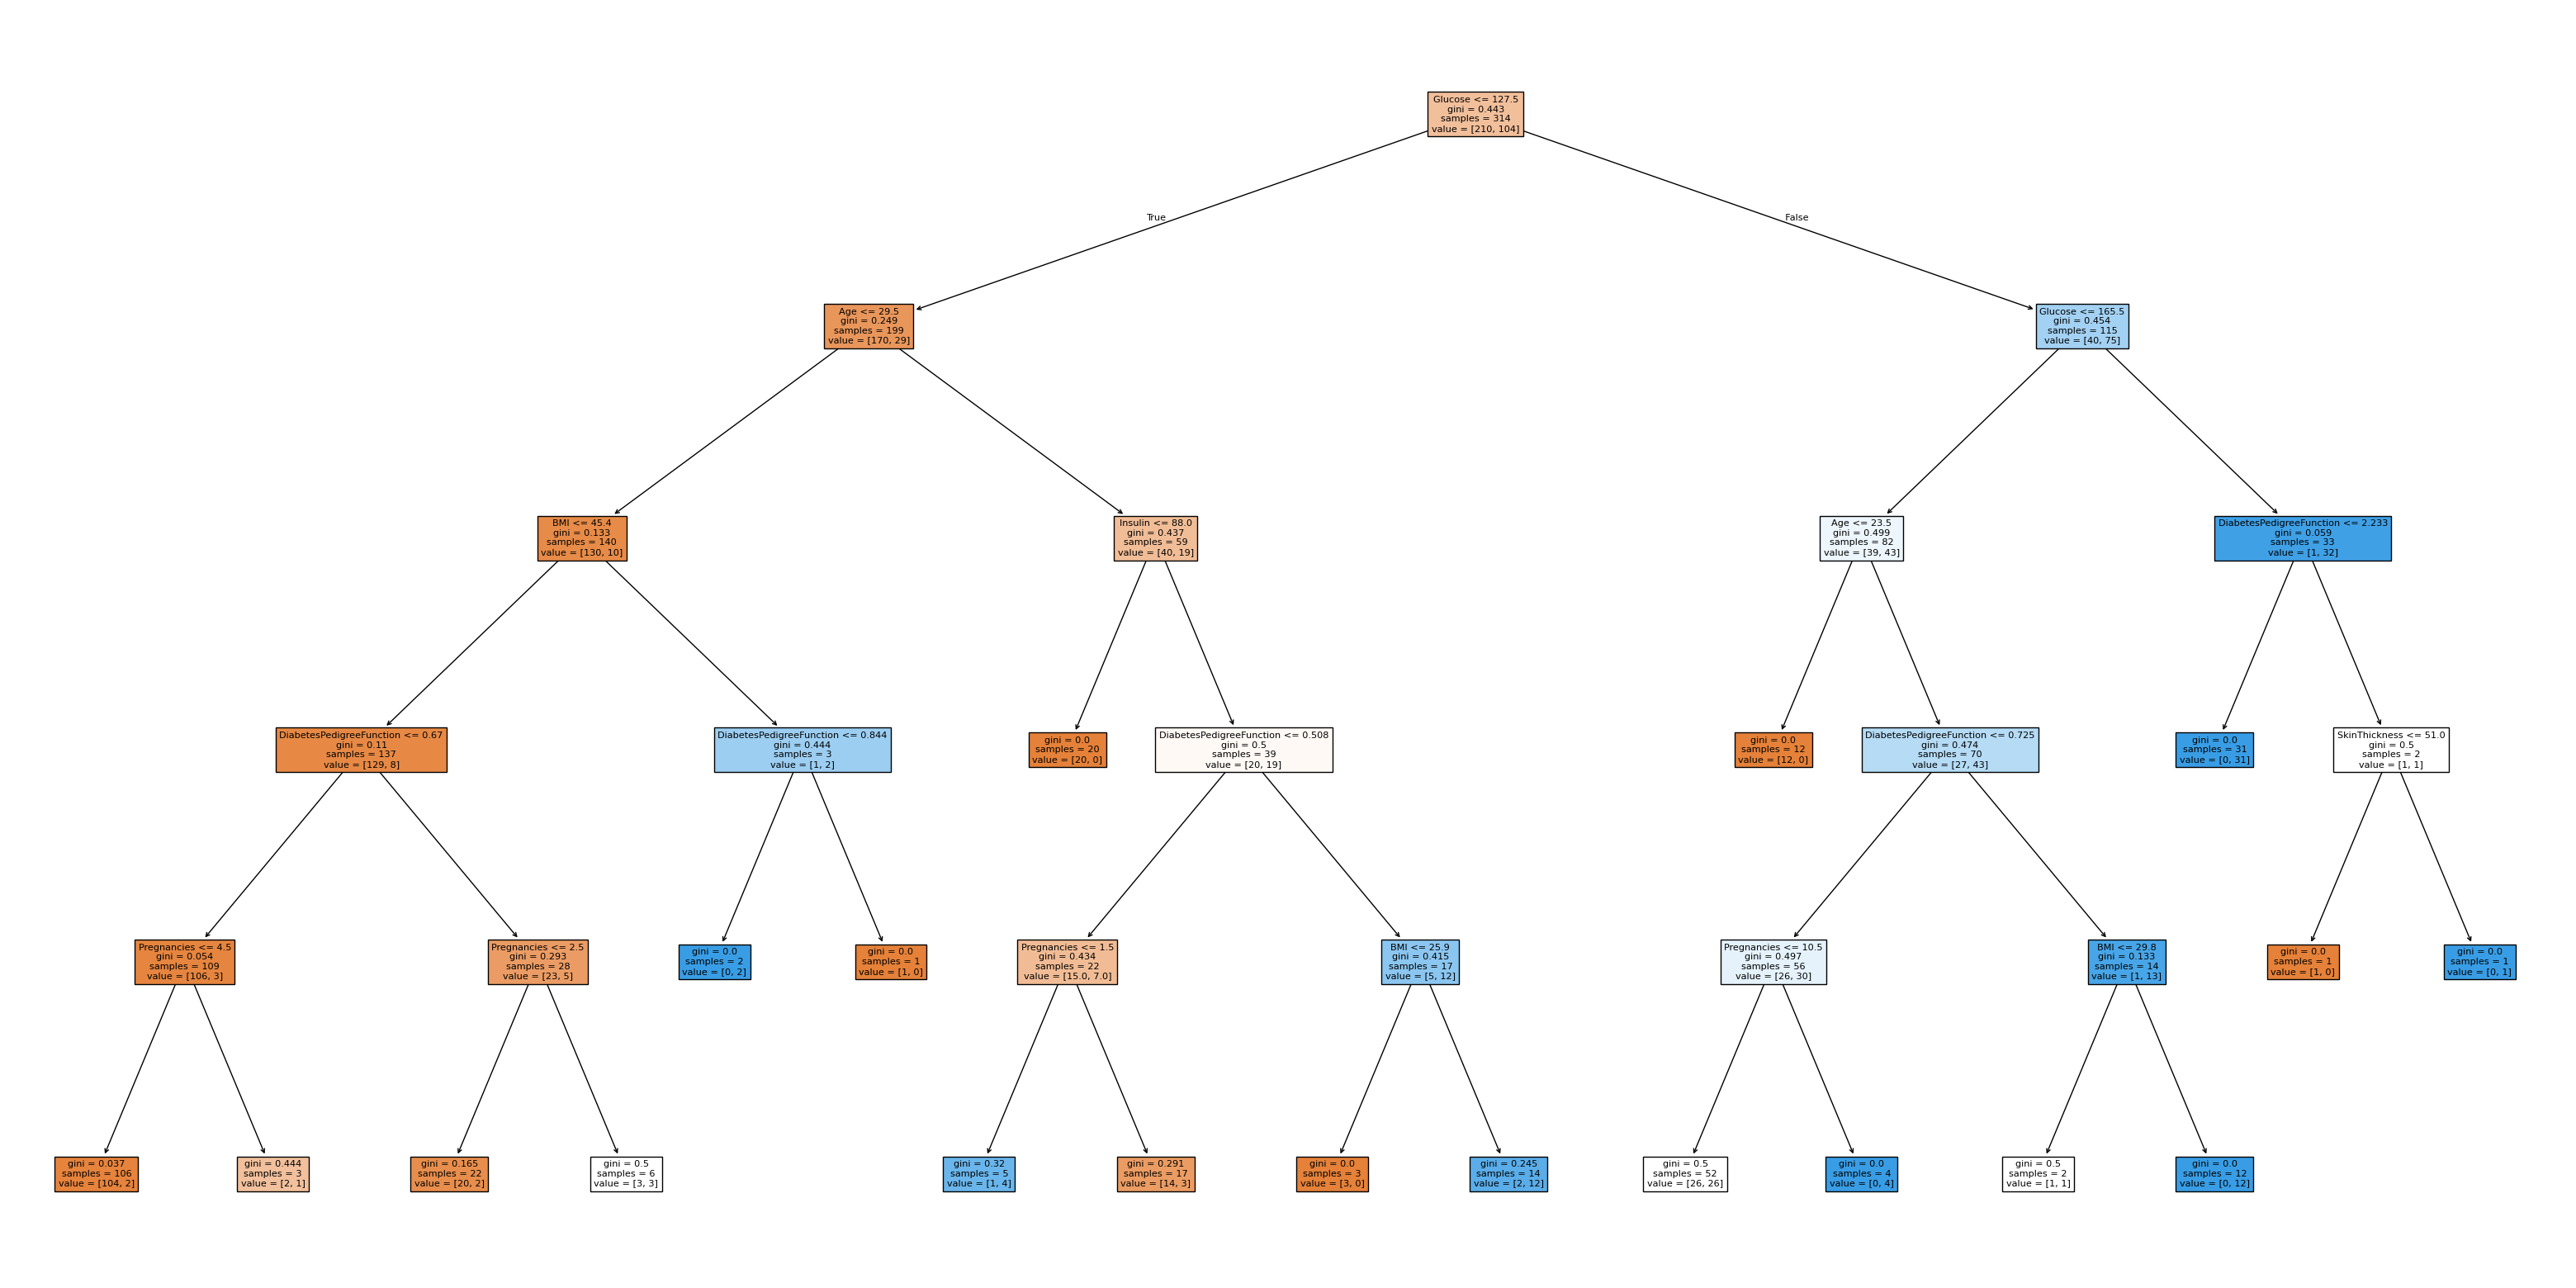

In [6]:
plt.figure(figsize=(40, 20))
tree.plot_tree(dt_classifier_model_filtrado,
               feature_names=list(X_train_filtrado.columns),
               filled=True)
plt.show()

#### Si no ajustamos la profundidad del árbol pueden haber gráficos que no podamos manejar con facilidad

#### Predicción 

In [7]:
y_pred_test_fil = dt_classifier_model_filtrado.predict(X_test_filtrado)
y_pred_test_fil

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [8]:
y_pred_train_fil = dt_classifier_model_filtrado.predict(X_train_filtrado)
y_pred_train_fil

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,

#### Métricas

In [9]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.869427,0.869427,0.869427,0.869427
Test set,0.772152,0.772152,0.772152,0.772152


In [10]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.869427,0.836448,0.900710,0.810165
Test set,0.772152,0.736667,0.742424,0.732221


In [11]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.869427,0.861241,0.881869,0.869427
Test set,0.772152,0.769705,0.768316,0.772152


#### Matriz de confusión

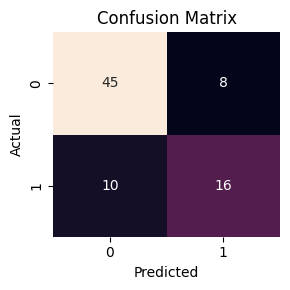

In [12]:
diabetes_cm = confusion_matrix(y_test_filtrado, y_pred_test_fil)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Oservamos que cuanto menos profundidad tiene el árbol, las métricas de y-test son mejores pero las de y-train van empeorando y que las métricas en micro o weighted son las que mejor resultado dan, trás varias pruebas de paramétros obtengo que el mejor valor para la profundidad está entre 3 y 5

## 2. Dataset con valores nulos remplazados por la moda

In [13]:
df_train_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-mode.csv")
df_test_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-mode.csv")

### Generamos los conjuntos de train y test

In [14]:
X_train_mode = df_train_mode.drop(["Outcome"], axis = 1)
y_train_mode = df_train_mode["Outcome"]
X_test_mode = df_test_mode.drop(["Outcome"], axis = 1)
y_test_mode = df_test_mode["Outcome"]

### Modelado y Ajuste

In [15]:
dt_classifier_model_mode = DecisionTreeClassifier(max_depth=5, random_state=24)
dt_classifier_model_mode.fit(X_train_mode, y_train_mode)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

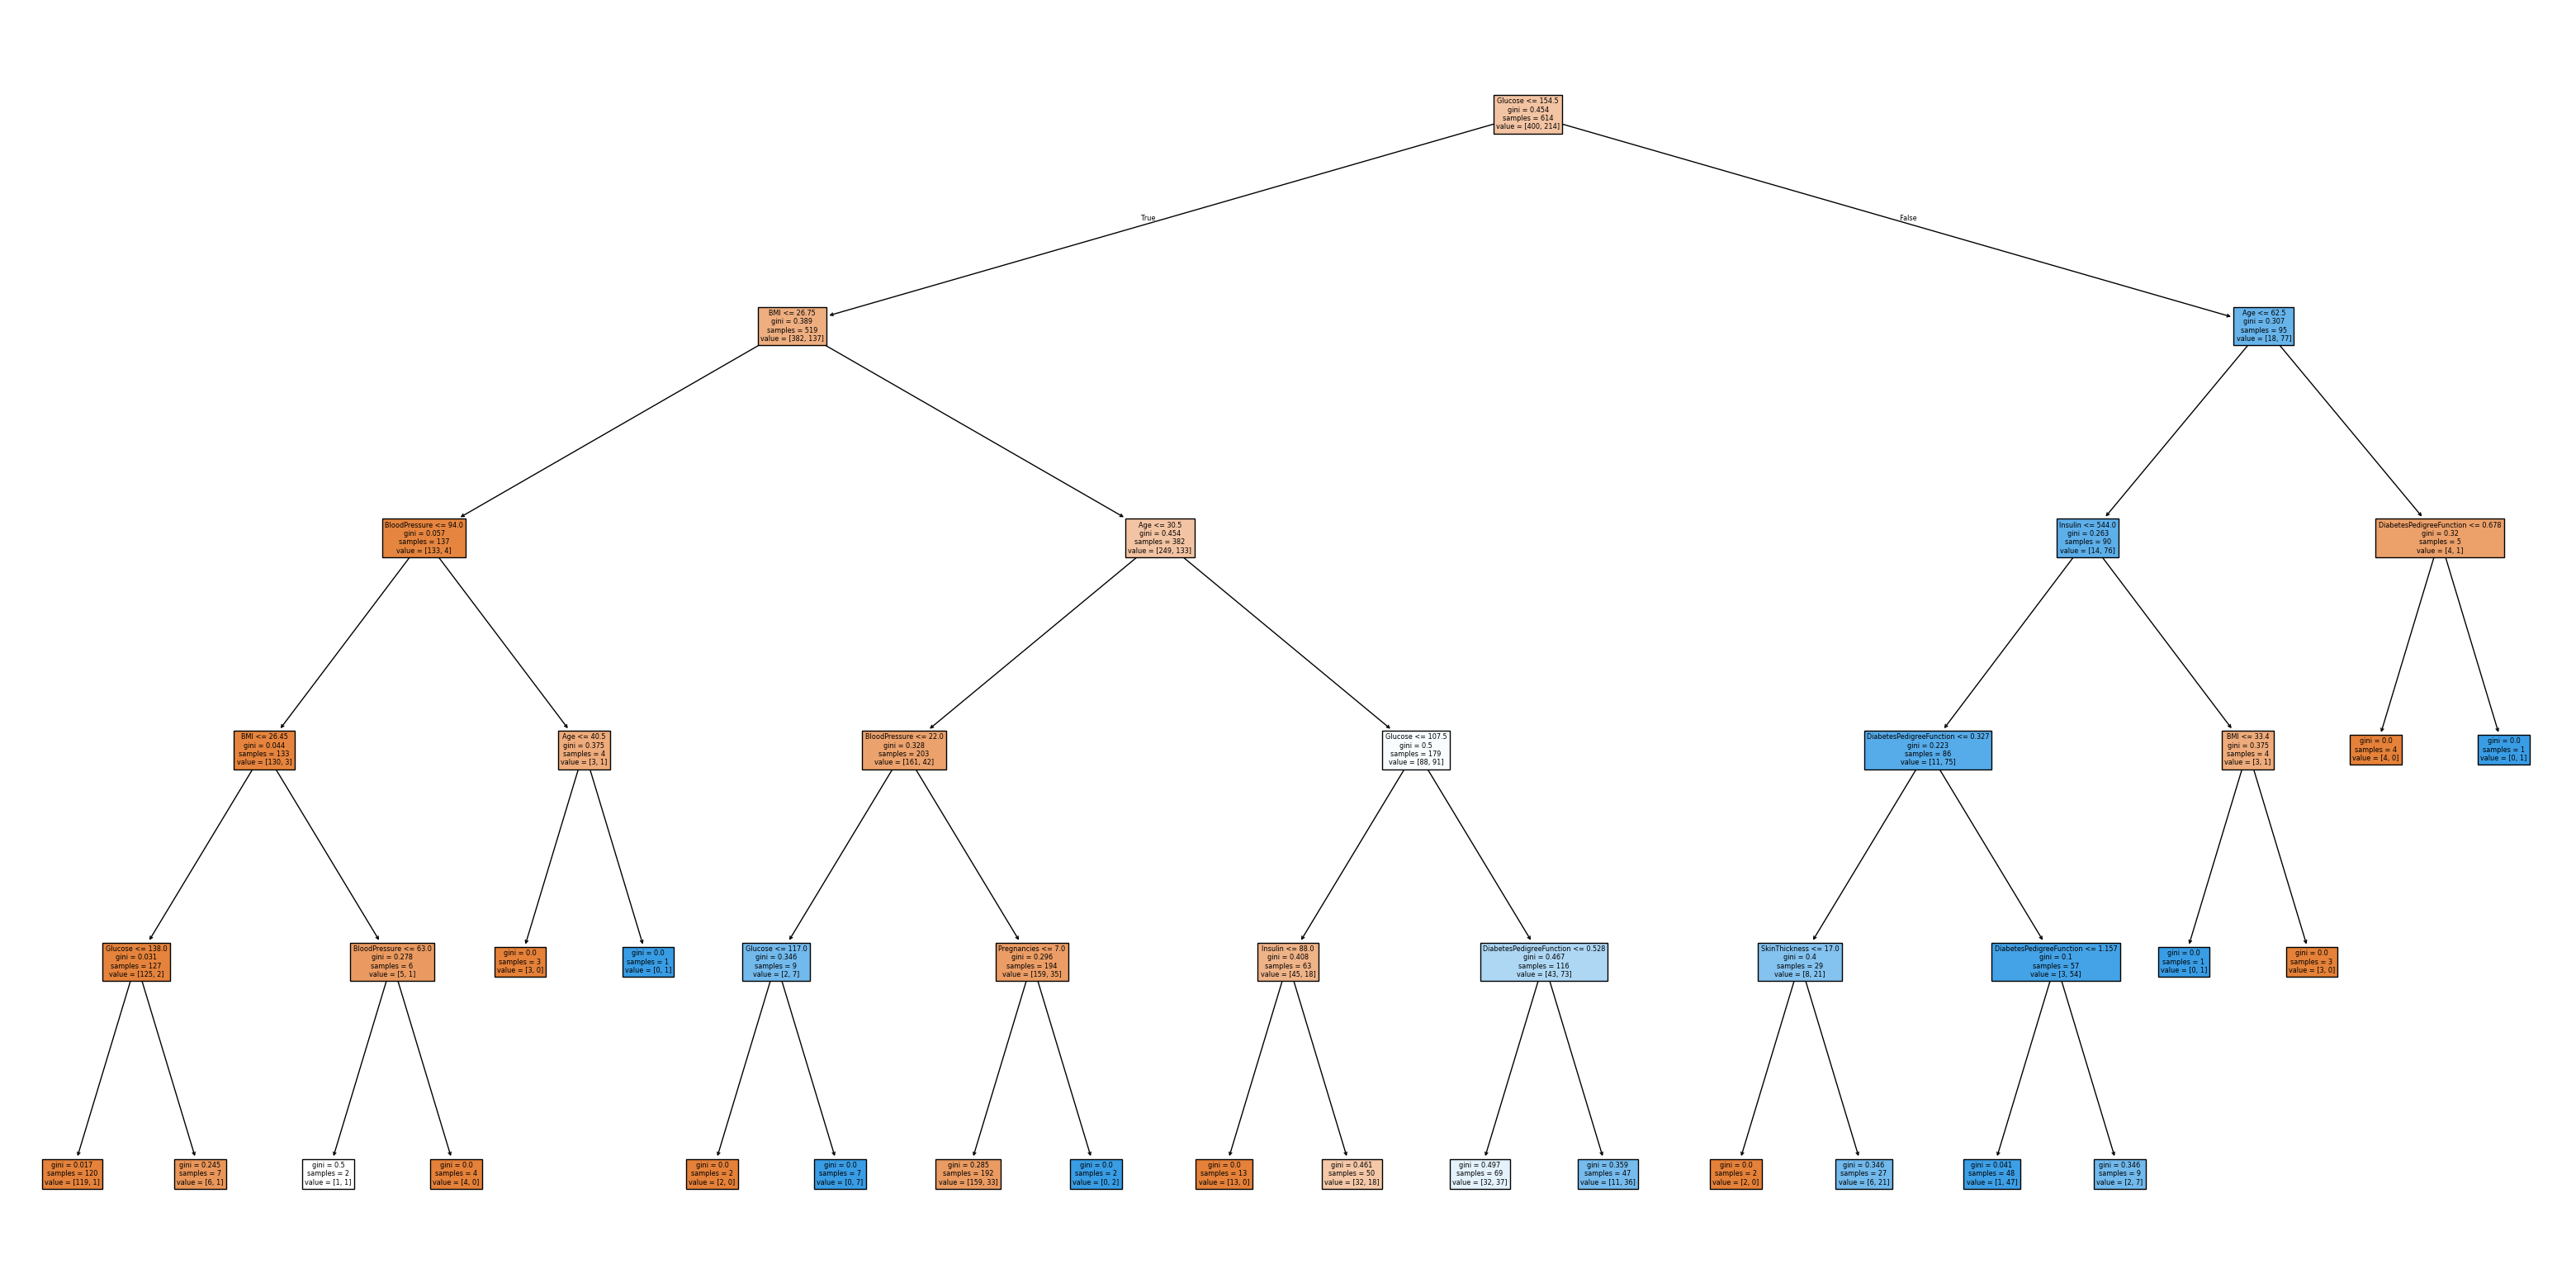

In [16]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model_mode,
               feature_names=list(X_train_mode.columns),
               filled=True)
plt.show()

#### Observamos que al tener más cantidad de datos el algoritmo se vuelve más complejo (a mismo nivel de profundidad)

#### Predicción 

In [17]:
y_pred_test_mode = dt_classifier_model_mode.predict(X_test_mode)
y_pred_test_mode

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [18]:
y_pred_train_mode = dt_classifier_model_mode.predict(X_train_mode)
y_pred_train_mode

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,

#### Métricas

In [19]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.827362,0.827362,0.827362
Test set,0.740260,0.740260,0.740260,0.740260


In [20]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.809502,0.810194,0.808832
Test set,0.740260,0.709653,0.714231,0.706296


In [21]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.827172,0.827000,0.827362
Test set,0.740260,0.737811,0.736404,0.740260


#### Matriz de confusión

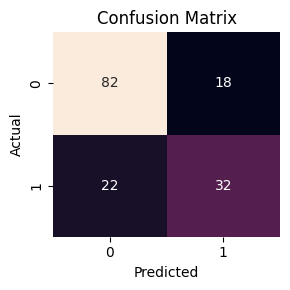

In [22]:
diabetes_cm = confusion_matrix(y_test_mode, y_pred_test_mode)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Observo que la tendencia general es que la profundidad entorno a 5 da mejores métricas

## 3. Dataset con valores nulos remplazados por los k-nearest neighbors

In [23]:
df_train_kn = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-kn.csv")
df_test_kn = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-kn.csv")

### Generamos los conjuntos de train y test

In [24]:
X_train = df_train_kn.drop(["Outcome"], axis = 1)
y_train = df_train_kn["Outcome"]
X_test = df_test_kn.drop(["Outcome"], axis = 1)
y_test = df_test_kn["Outcome"]

### Modelado y Ajuste

In [25]:
dt_classifier_model = DecisionTreeClassifier(max_depth=5, min_samples_split=5, min_samples_leaf=5, random_state=24) # Mejores parámetros hasta ahora
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

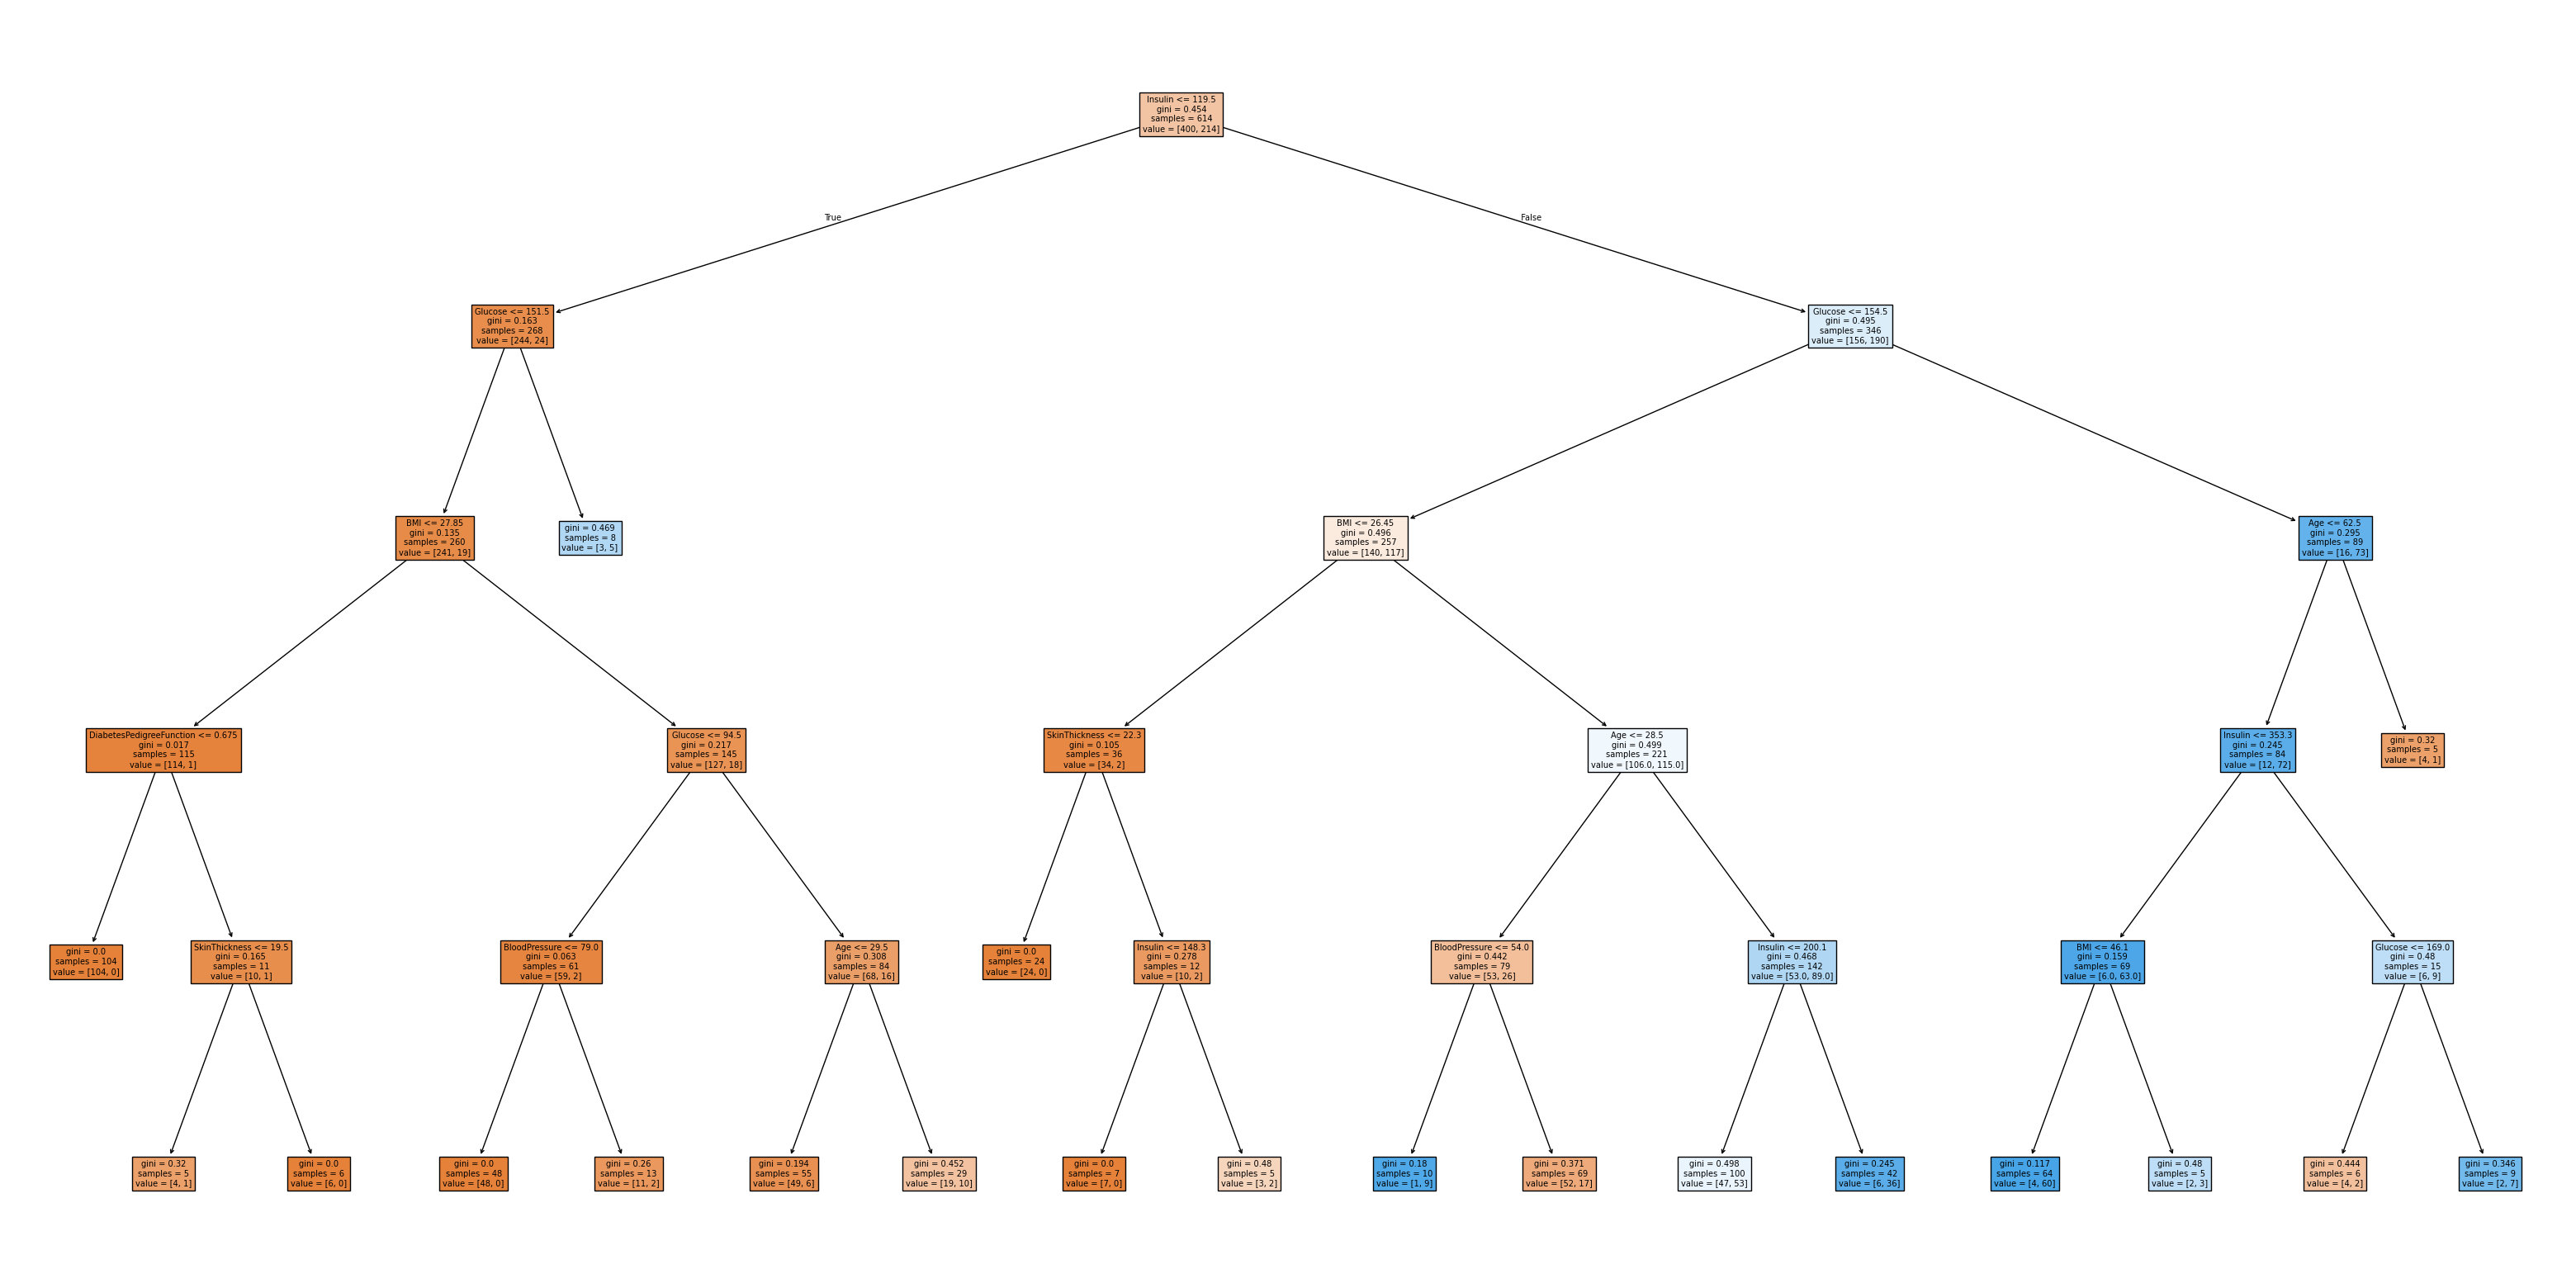

In [26]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Predicción 

In [27]:
y_pred_test = dt_classifier_model.predict(X_test)
y_pred_test

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1.,
       1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0.])

In [28]:
y_pred_train = dt_classifier_model.predict(X_train)
y_pred_train

array([1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1.,
       0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0.,
       0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1.,
       1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 0.

#### Métricas

In [29]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.827362,0.827362,0.827362
Test set,0.733766,0.733766,0.733766,0.733766


In [30]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.814444,0.808924,0.822956
Test set,0.733766,0.717456,0.713675,0.726852


In [31]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.827362,0.829275,0.833775,0.827362
Test set,0.733766,0.737733,0.746682,0.733766


#### Matriz de confusión

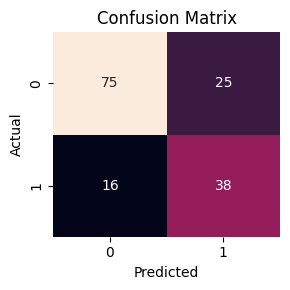

In [32]:
diabetes_cm = confusion_matrix(y_test, y_pred_test)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Conclusiones:

>- Después de varias pruebas, a profundidad máxima observamos que el modelo sufre overfitting (las métricas de train son perfectas) y que la visualización del árbol se vuelve muy compleja para poder manejarla
>- En todos los casos el dataset con datos truncados arroja mejores resultados en término de métricas, parece un indicador de que el modelo no generaliza bien, quizás por la falta de datos, la lógica me dice que el modelo que más se ajusta a la realidad es el de sustitución por k-nearest, pero puede pasar que los valores eliminados no estén distribuidos de forma totalmente aleatoria y se haya metido ruido en el conjunto de datos o que la sustitución no haya sido adecuada porque los valores próximos no se distribuyen uniformemente
>- Jugando con los parámetros del modelo podemos mejorar los resultados

## Buscamos los mejores parámetros con `GridSearchCV`

### Definición de parámetros y métricas

In [33]:
param_grid = {'max_depth': [3, 5, 7, 10, 15, 20, None],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 2, 4, 8],
              'max_features': ['sqrt', 'log2', None]
    }
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
grid_search = GridSearchCV(estimator=dt_classifier_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring=scoring,
                           refit='accuracy',  # Métrica principal para seleccionar el mejor
                           n_jobs=-1,
                           verbose=1
    )


#### Entrenamiento de la cuadrícula

In [34]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 336 candidates, totalling 1680 fits


,estimator,DecisionTreeC...ndom_state=24)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,"['accuracy', 'precision_weighted', ...]"
,n_jobs,-1
,refit,'accuracy'
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


#### Mejores estimador y parámetros

In [35]:
grid_search.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
grid_search.best_params_

{'max_depth': 15,
 'max_features': 'log2',
 'min_samples_leaf': 8,
 'min_samples_split': 2}

#### Visualización del arbol de decisión

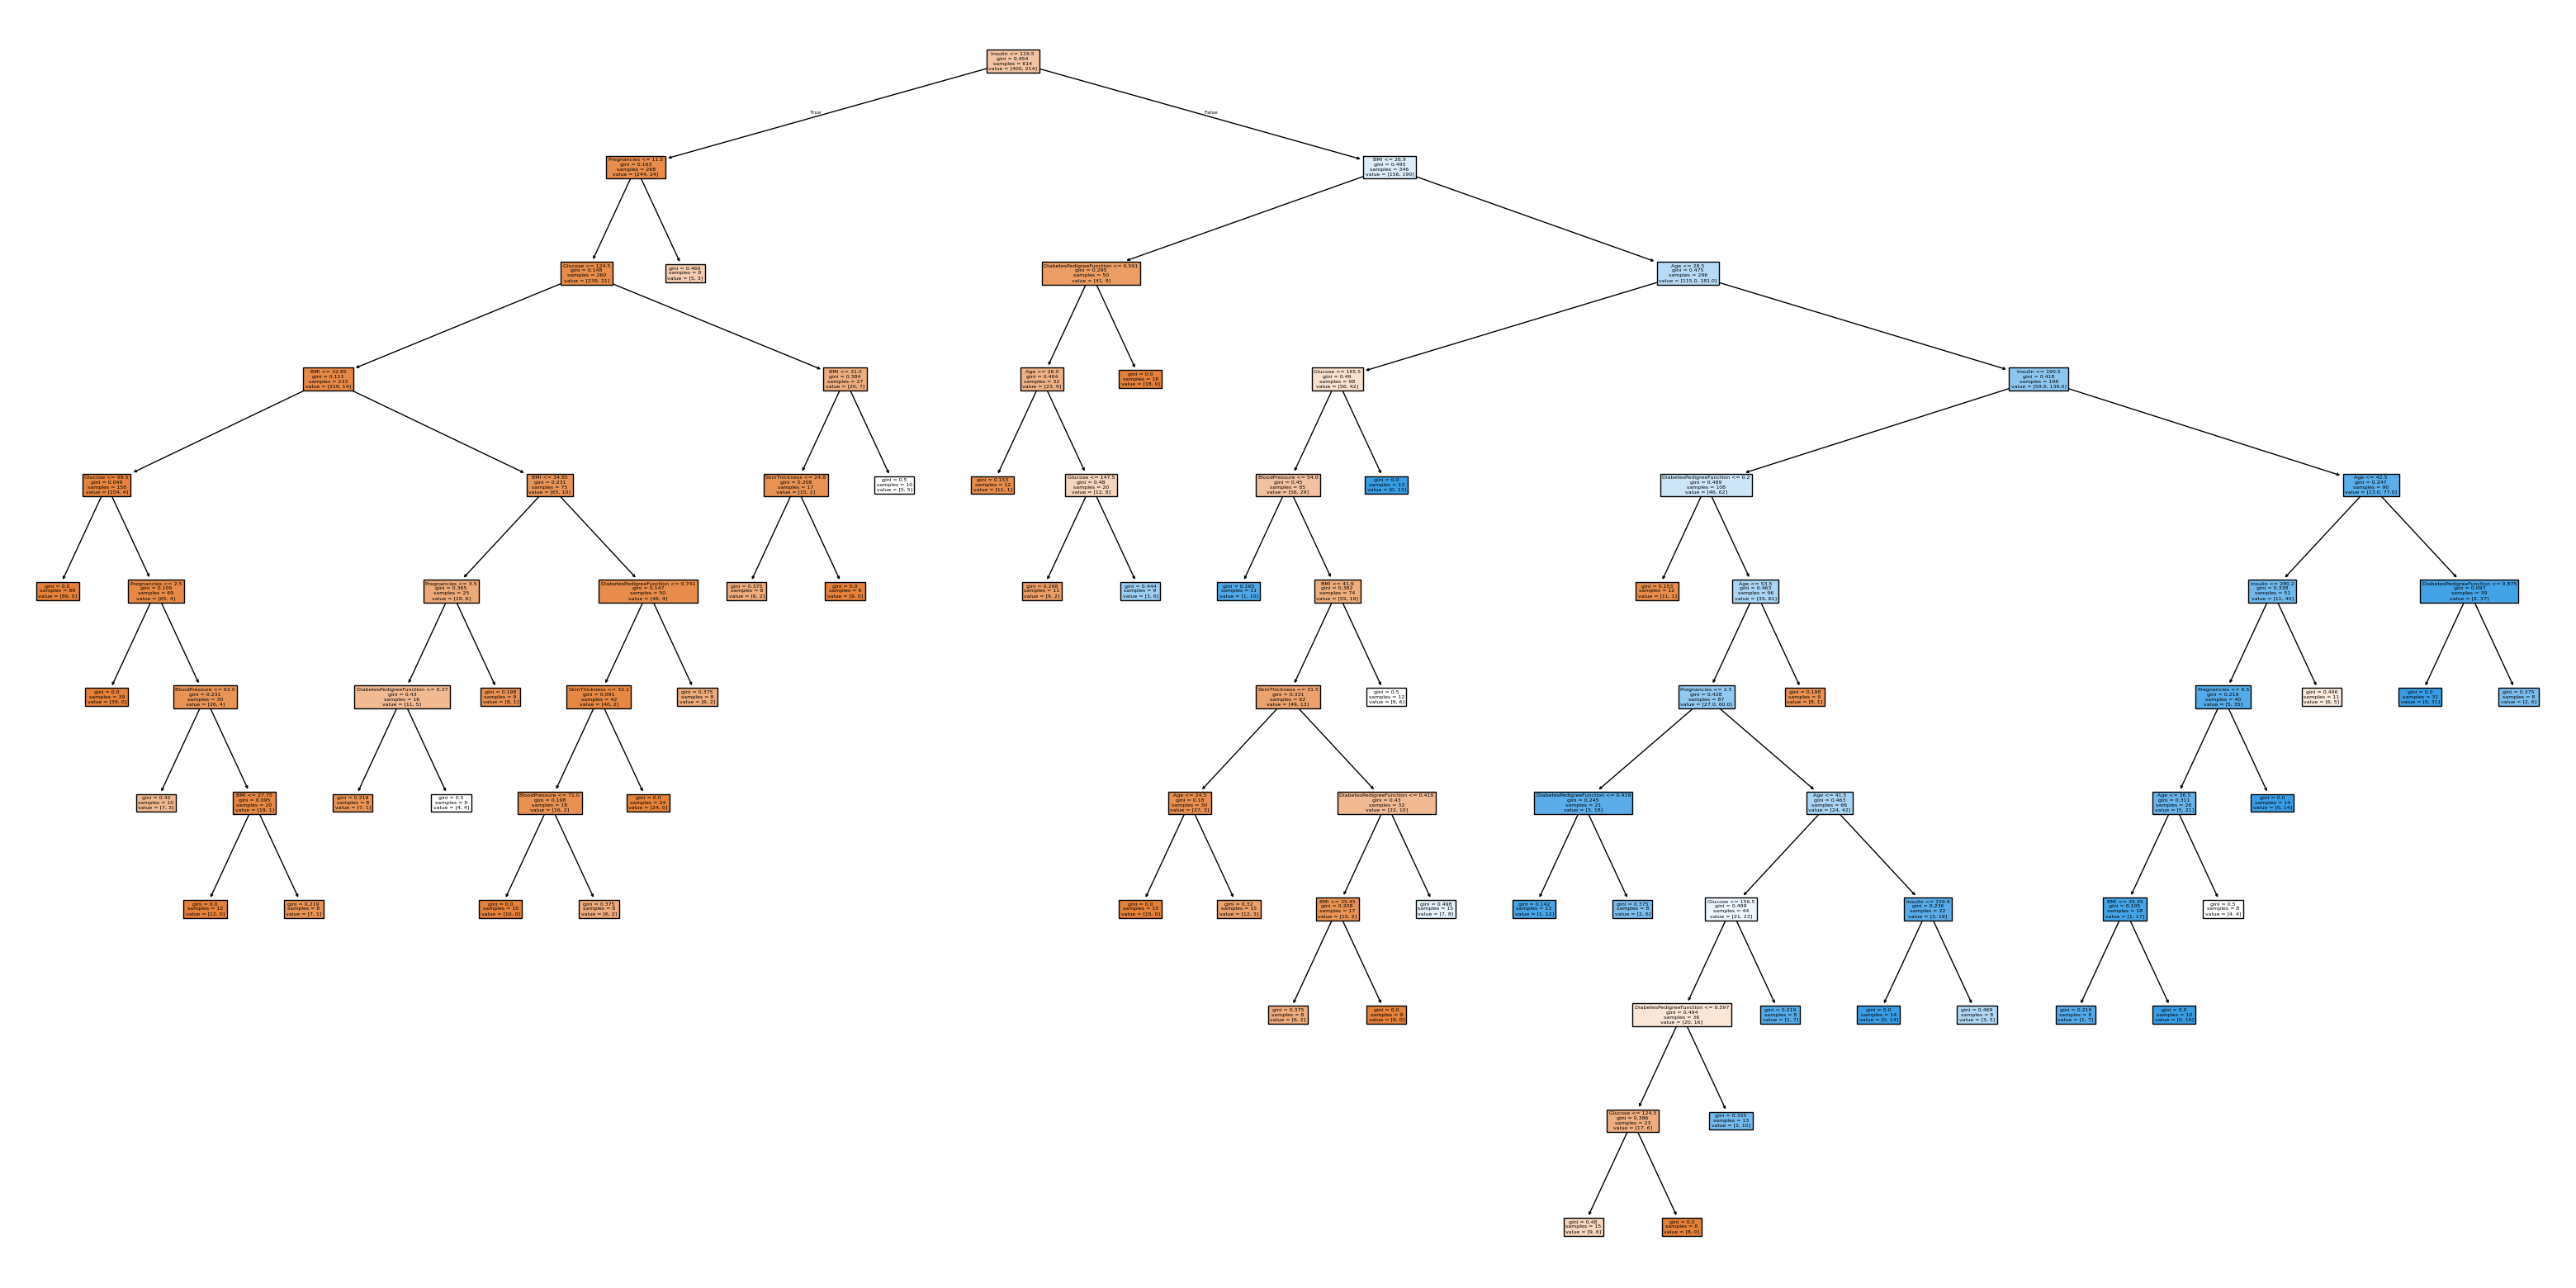

In [37]:
plt.figure(figsize=(40, 20))
tree.plot_tree(grid_search.best_estimator_,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Predicción 

In [38]:
best_model = grid_search.best_estimator_
y_pred_test_grid = best_model.predict(X_test)
y_pred_test_grid

array([0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
       1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [39]:
y_pred_train_grid = best_model.predict(X_train)
y_pred_train_grid

array([1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 0.,
       1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0.

#### Métricas

In [40]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.871336,0.871336,0.871336,0.871336
Test set,0.733766,0.733766,0.733766,0.733766


In [41]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.871336,0.852971,0.870621,0.841495
Test set,0.733766,0.680255,0.713906,0.671481


In [42]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.871336,0.868712,0.871157,0.871336
Test set,0.733766,0.719327,0.725326,0.733766


## Comparativa entre modelos

In [ ]:
metricas = {'recall filtrado': recall_score(y_test_filtrado, y_pred_test_fil, average='micro'),
            'recall mode': recall_score(y_test_mode, y_pred_test_mode, average='micro'),
            'recall knn': recall_score(y_test, y_pred_test, average='micro'),
            'recall gridsearch': recall_score(y_test, y_pred_test_grid, average='micro')
           
}
metricas

{'recall filtrado': 0.7721518987341772,
 'recall mode': 0.7402597402597403,
 'recall knn': 0.7337662337662337,
 'recall gridsearch': 0.7337662337662337}

### Observamos que la cuadrícula de hiperparametros no mejora el resultado

| Modelo           | Recall             |
|------------------|--------------------|
| Filtrado         | 0.7722             |
| Mode             | 0.7403             |
| KNN              | 0.7338             |
| GridSearch       | 0.7338             |


## Guardado de modelos

In [44]:
models = {'dt_classifier_model_filtrado' : dt_classifier_model_filtrado,
          'dt_classifier_model_mode' : dt_classifier_model_mode,
          'dt_classifier_model' : dt_classifier_model  
          }
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelos-decision-tree.pkl', 'wb') as file:
    pickle.dump(models, file)